In [ ]:
#  Dolandırıcılık (Fraud) oranına bakalım (Hedef Değişkenimiz)
print("Fraud Dağılımı:")
print(df['FraudFound_P'].value_counts())
print("\nOransal Dağılım:")
print(df['FraudFound_P'].value_counts(normalize=True))

# 2. Sütunların veri tiplerini ve doluluk oranlarını inceleyelim
print("\nVeri Tipleri ve Eksik Değerler:")
print(df.info())

# 3. Sayısal sütunların temel istatistikleri
print("\nİstatistiksel Özet:")
display(df.describe())

Fraud Dağılımı:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Oransal Dağılım:
FraudFound_P
0    0.940143
1    0.059857
Name: proportion, dtype: float64

Veri Tipleri ve Eksik Değerler:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-nu

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


C:\Users\tunah\AppData\Local\Temp\ipykernel_22520\3104097179.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudFound_P', data=df, palette='viridis')


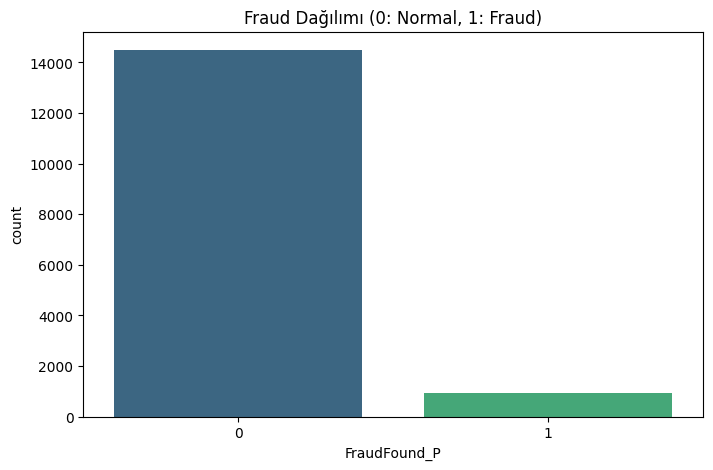

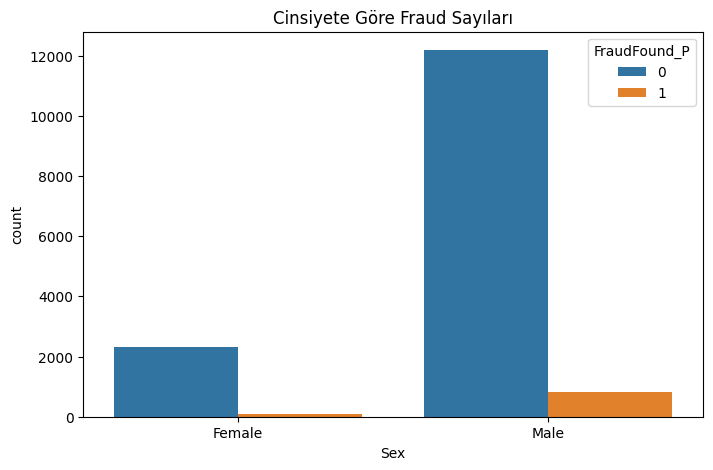

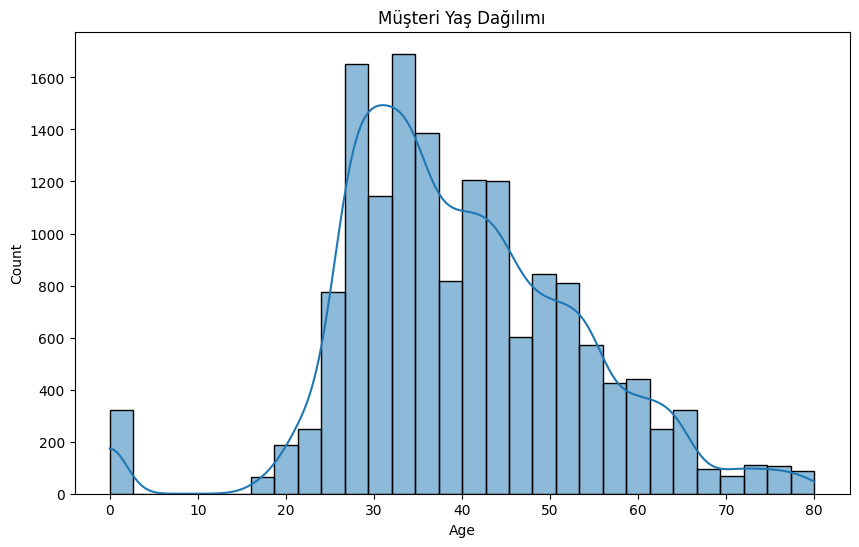

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os


if not os.path.exists('../plots'):
    os.makedirs('../plots')

#  Hedef Değişken Dağılımı (Bar Plot)
plt.figure(figsize=(8, 5))
sns.countplot(x='FraudFound_P', data=df, palette='viridis')
plt.title('Fraud Dağılımı (0: Normal, 1: Fraud)')
plt.savefig('../plots/fraud_distribution.png')
plt.show()

#  Cinsiyete Göre Fraud Durumu
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='FraudFound_P', data=df)
plt.title('Cinsiyete Göre Fraud Sayıları')
plt.savefig('../plots/sex_vs_fraud.png')
plt.show()

#  Yaş Dağılımı (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Müşteri Yaş Dağılımı')
plt.savefig('../plots/age_distribution.png')
plt.show()

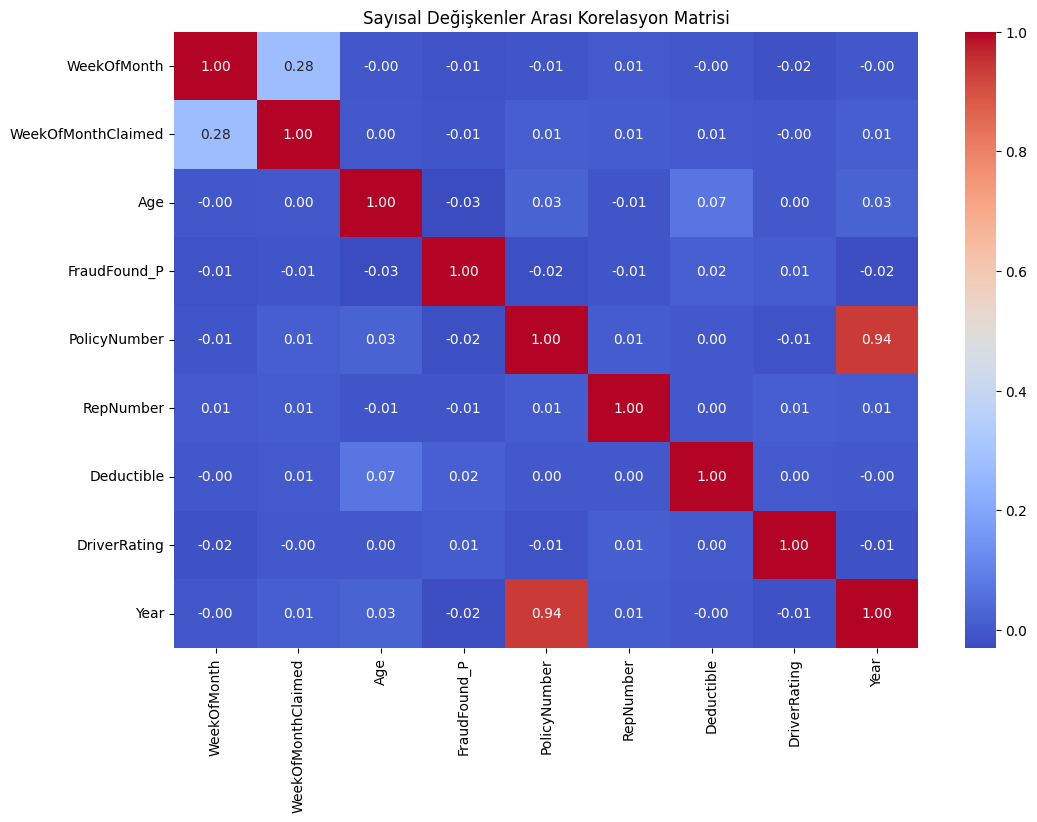

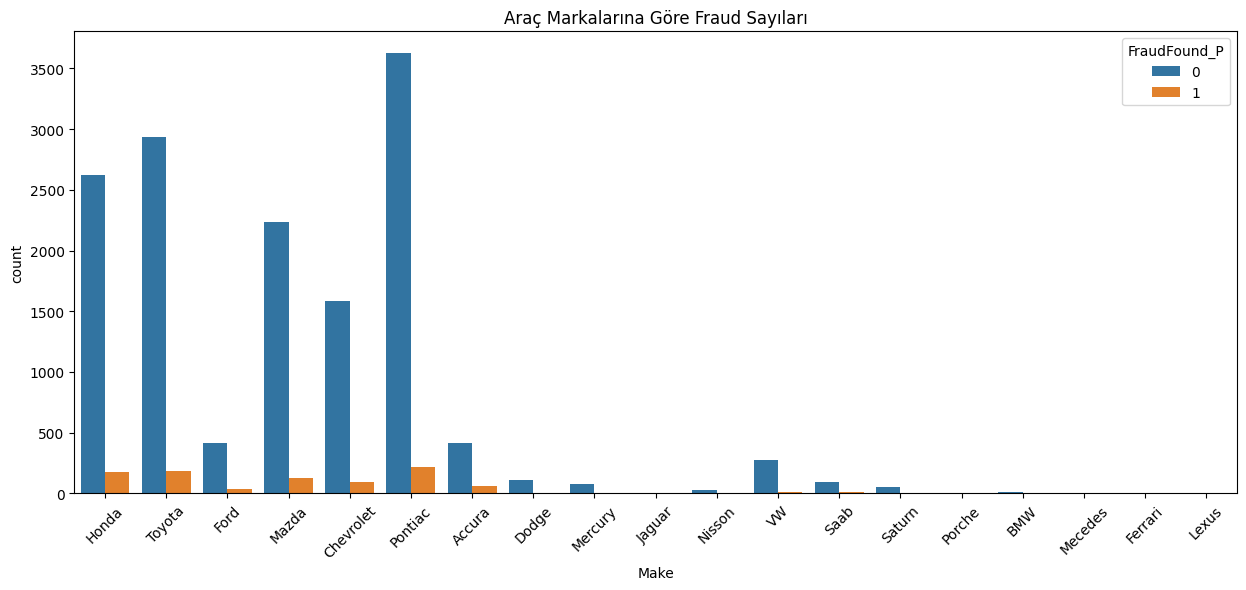

In [4]:
# Sayısal sütunlar arasındaki ilişkiyi görelim
plt.figure(figsize=(12, 8))
# Sadece sayısal sütunları seçiyoruz
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.savefig('../plots/correlation_matrix.png')
plt.show()

# Bonus: Araç markalarına göre Fraud durumu (En çok hangi marka fraud yapıyor?)
plt.figure(figsize=(15, 6))
sns.countplot(x='Make', hue='FraudFound_P', data=df)
plt.xticks(rotation=45)
plt.title('Araç Markalarına Göre Fraud Sayıları')
plt.savefig('../plots/make_vs_fraud.png')
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz
# Klasör yapımız gereği notebooks içinden bir üst klasöre çıkıp data/raw'a gidiyoruz
df = pd.read_csv("../data/raw/fraud_oracle.csv")

# İlk 5 satırı ekrana basalım
print("Veri Seti İlk 5 Satır:")
display(df.head())

# Verinin boyutuna (satır, sütun) bakalım
print(f"\nVeri Boyutu: {df.shape}")

Veri Seti İlk 5 Satır:


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision



Veri Boyutu: (15420, 33)
